# PenjuruBus — Inference Notebook

In [2]:
import os, json, joblib, numpy as np, pandas as pd
ROOT = r'D:/penjurubus'
PROC_DIR = os.path.join(ROOT, 'data', 'processed_v3')
MODEL_DIR = os.path.join(ROOT, 'models')
PRED_DIR = os.path.join(ROOT, 'data', 'predictions_v4_search')
os.makedirs(PRED_DIR, exist_ok=True)
TARGET_COL = 'is_candidate_stop'

In [3]:
TEGAL_PATH = os.path.join(PROC_DIR, 'tegal', 'features_v3.parquet')
tegal_df = pd.read_parquet(TEGAL_PATH)
artifact = joblib.load(os.path.join(MODEL_DIR, 'step4_best_model.joblib'))
model = artifact['model']; thr = artifact['threshold']; cols = artifact['feature_cols']

In [4]:
drop_cols = [c for c in ['grid_id', 'city', 'label_method', 'geometry', 'centroid_x', 'centroid_y', TARGET_COL] if c in tegal_df.columns]
X = tegal_df.drop(columns=drop_cols, errors='ignore').copy()
for c in artifact['num_cols']:
    if c in X.columns:
        med = X[c].median()
        X[c] = X[c].fillna(med)
for c in artifact['cat_cols']:
    if c in X.columns:
        X[c] = X[c].fillna('missing').astype(str)
for c in artifact['num_cols']:
    if c in X.columns:
        mu = X[c].mean(); sd = X[c].std(ddof=0); sd = 1.0 if pd.isna(sd) or sd == 0 else sd
        X[c] = (X[c] - mu) / sd
for c in artifact['cat_cols']:
    if c in X.columns:
        uniq = list(pd.Series(X[c].unique()).dropna())
        if len(uniq) <= 2:
            mapping = {v: i for i, v in enumerate(sorted(uniq))}
            X[c] = X[c].map(mapping).fillna(0).astype(float)
        else:
            X = X.drop(columns=[c])
X = X.reindex(columns=cols, fill_value=0)

In [5]:
prob = model.predict_proba(X)[:, 1]
pred_thr = (prob >= thr).astype(int)
if pred_thr.sum() == 0:
    top_n = max(10, int(len(prob) * 0.05))
    order = np.argsort(-prob)
    pred = np.zeros_like(pred_thr)
    pred[order[:top_n]] = 1
    rule = f'top_{top_n}'
else:
    pred = pred_thr
    rule = f'thr_{thr:.2f}'
out = tegal_df.copy()
out['score'] = prob
out['pred_label'] = pred
out['selected_rule'] = rule
out = out.sort_values('score', ascending=False).reset_index(drop=True)
out.to_pickle(os.path.join(PRED_DIR, 'tegal_scored_all.pkl'))
out.head(20).to_csv(os.path.join(PRED_DIR, 'tegal_top20.csv'), index=False)
out.head(50).to_csv(os.path.join(PRED_DIR, 'tegal_top50.csv'), index=False)
print('positives:', int(pred.sum()), '/', len(pred), '| rule:', rule)

positives: 13 / 194 | rule: thr_0.95


In [6]:
if hasattr(model, 'feature_importances_'):
    imp = pd.DataFrame({'feature': cols, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
elif hasattr(model, 'coef_'):
    imp = pd.DataFrame({'feature': cols, 'importance': np.abs(model.coef_[0])}).sort_values('importance', ascending=False)
else:
    imp = pd.DataFrame({'feature': cols, 'importance': np.nan})
imp.to_csv(os.path.join(PRED_DIR, 'feature_importance_inference.csv'), index=False)
print(imp.head(10))

                 feature  importance
3         building_count    9.049736
2              poi_count    0.320161
6           road_density    0.133024
5            road_length    0.131525
0                area_m2    0.067306
7  dist_to_nearest_halte    0.014398
4            halte_count    0.006230
1             population    0.000000
8            pop_density    0.000000
9             pop_x_area    0.000000


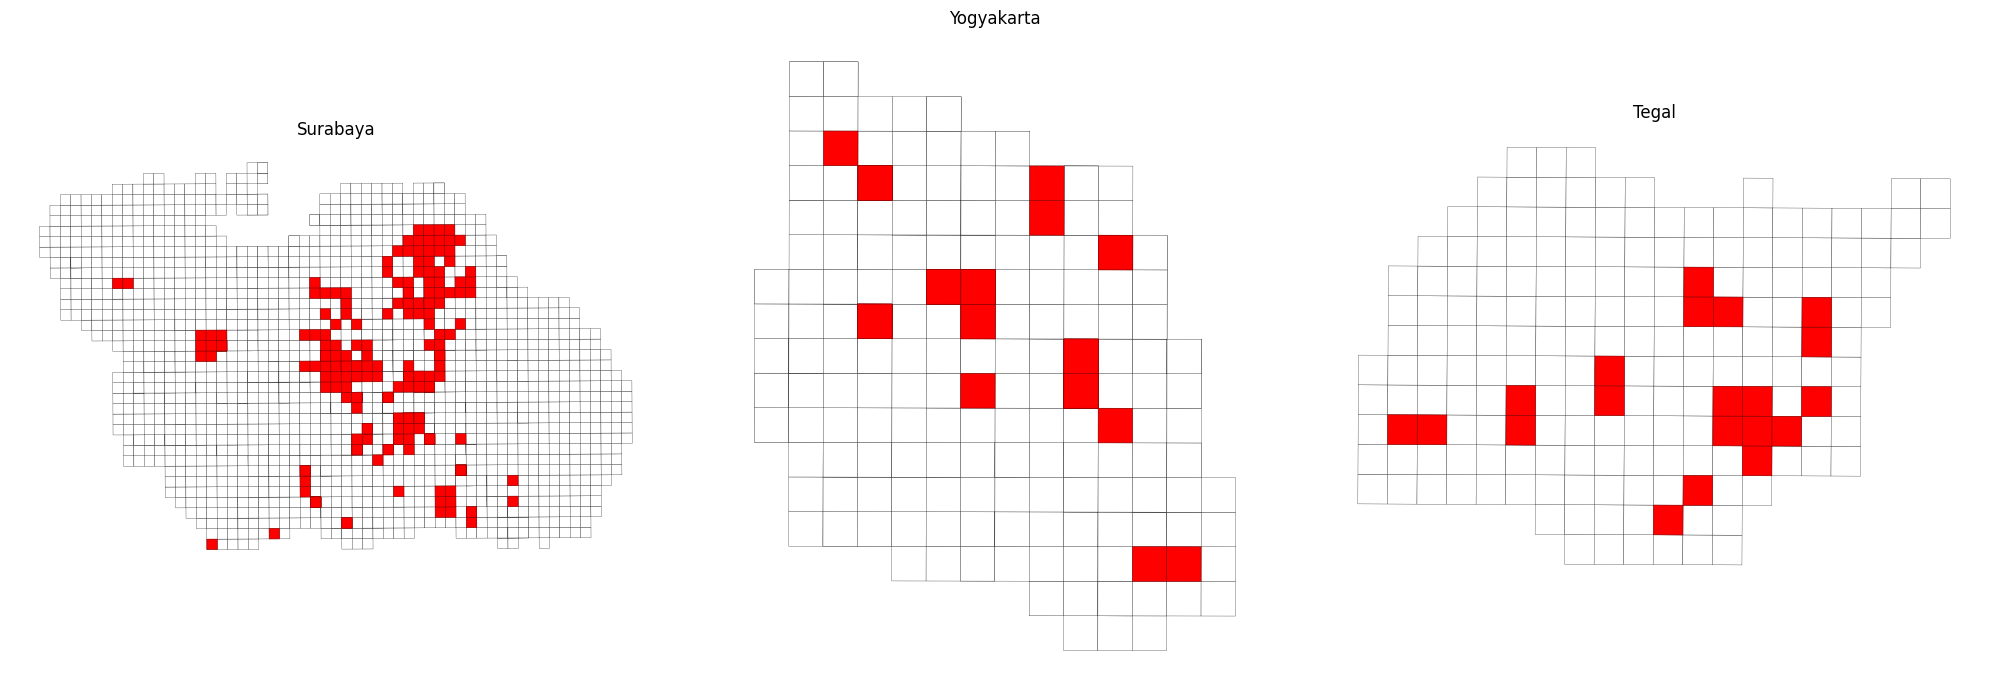

In [7]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

ROOT = r"D:/penjurubus"
PROC_DIR = os.path.join(ROOT, "data", "processed_v3")
PRED_DIR = os.path.join(ROOT, "data", "predictions_v4_search")
OUT_DIR = os.path.join(ROOT, "output_visual")
os.makedirs(OUT_DIR, exist_ok=True)

CITY_FILES = {
    "Surabaya": os.path.join(PROC_DIR, "surabaya", "features_v3.parquet"),
    "Yogyakarta": os.path.join(PROC_DIR, "yogyakarta", "features_v3.parquet"),
    "Tegal": os.path.join(PROC_DIR, "tegal", "features_v3.parquet"),
}

TEGAL_TOP20 = os.path.join(PRED_DIR, "tegal_top20.csv")


def read_any(path):
    if path.lower().endswith(".parquet"):
        return pd.read_parquet(path)
    elif path.lower().endswith(".pkl") or path.lower().endswith(".pickle"):
        return pd.read_pickle(path)
    elif path.lower().endswith(".csv"):
        return pd.read_csv(path)
    else:
        raise ValueError(f"Unsupported file: {path}")


def to_gdf(df):
    if "geometry" not in df.columns:
        return None

    try:
        return gpd.read_parquet(df)
    except Exception:
        pass

    try:
        gdf = gpd.GeoDataFrame(df.copy(), geometry=gpd.GeoSeries.from_wkb(df["geometry"]))
        if gdf.crs is None:
            gdf = gdf.set_crs("EPSG:4326", allow_override=True)
        return gdf
    except Exception:
        try:
            gdf = gpd.GeoDataFrame(df.copy(), geometry=gpd.GeoSeries.from_wkt(df["geometry"].astype(str)))
            if gdf.crs is None:
                gdf = gdf.set_crs("EPSG:4326", allow_override=True)
            return gdf
        except Exception:
            return None


fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (city, path) in zip(axes, CITY_FILES.items()):
    df = read_any(path)
    gdf = to_gdf(df)

    if gdf is None:
        ax.set_title(f"{city} - geometry tidak terbaca")
        ax.axis("off")
        continue

    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326", allow_override=True)

    gdf = gdf.to_crs("EPSG:3857")
    gdf.plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)

    if "is_candidate_stop" in gdf.columns:
        cand = gdf[gdf["is_candidate_stop"] == 1]
        if len(cand) > 0:
            cand.plot(ax=ax, color="red", edgecolor="darkred", linewidth=0.4)

    ax.set_title(city)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "grid_map_3cities.png"), dpi=300, bbox_inches="tight")
plt.show()